# Homework Starter: Final Reporting

This notebook helps you generate plots, annotate assumptions, and prepare a stakeholder-ready deliverable.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib

## Executive Summary
- Baseline scenario shows steady returns with moderate volatility.
- Imputation and outlier adjustments create small variations in return and risk.
- Key assumptions and sensitivity analysis highlight decision risks and implications.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
sns.set(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
np.random.seed(101)

## Load Your Data

You can load your real results or use a generated synthetic dataset as fallback.

In [3]:
data_path = Path('data/processed/final_results.csv')

if data_path.exists():
    df = pd.read_csv(data_path)
else:
    # Synthetic fallback dataset
    df = pd.DataFrame({
        'scenario': ['baseline','alt_impute','alt_outlier'],
        'return': [0.12, 0.11, 0.135],
        'volatility': [0.18, 0.185, 0.19],
        'sharpe': [0.56, 0.49, 0.61],
        'assumption': ['imputation','imputation','outlier_rule'],
        'value': ['median','mean','3sigma'],
        'Category': np.random.choice(['X','Y','Z'], 3),
        'MetricA': np.random.normal(75, 15, 3),
        'MetricB': np.random.normal(150, 30, 3),
        'Date': pd.date_range('2025-02-01', periods=3)
    })
df.head()

,scenario,return,volatility,sharpe,assumption,value,Category,MetricA,MetricB,Date
0,baseline,0.120,0.180,0.56,imputation,median,Y,75.037206,99.563014,2025-02-01
1,alt_impute,0.110,0.185,0.49,imputation,mean,Z,74.456082,175.913737,2025-02-02
2,alt_outlier,0.135,0.190,0.61,outlier_rule,3sigma,Y,84.236667,128.274684,2025-02-03


## Helper: Export Directory

In [4]:
img_dir = Path('reports/images')
img_dir.mkdir(parents=True, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(img_dir / name, dpi=300)
    print(f'Saved {name}')

## Chart 1: Risk–Return Scatter

Saved risk_return.png


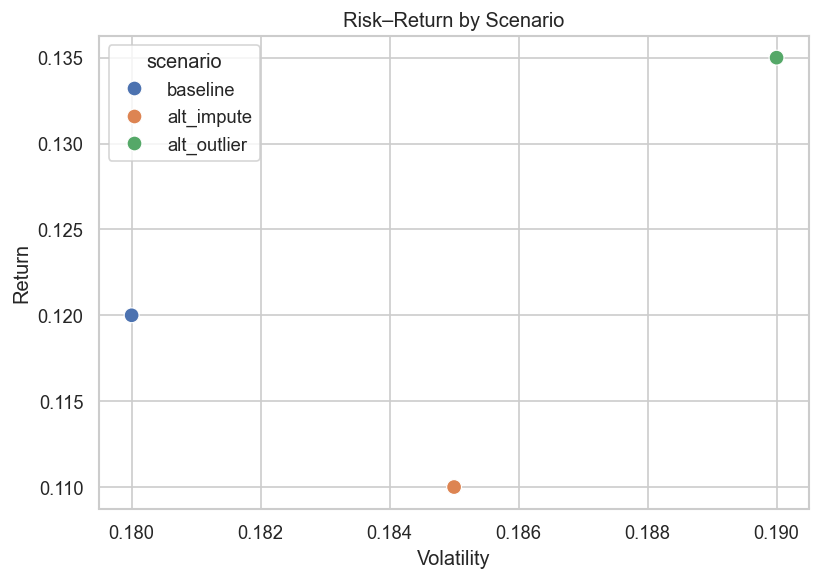

In [5]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='volatility', y='return', hue='scenario', s=80)
plt.title('Risk–Return by Scenario')
plt.xlabel('Volatility')
plt.ylabel('Return')
savefig('risk_return.png')
plt.show()

## Chart 2: Return by Scenario (Bar Chart)

Saved return_by_scenario.png


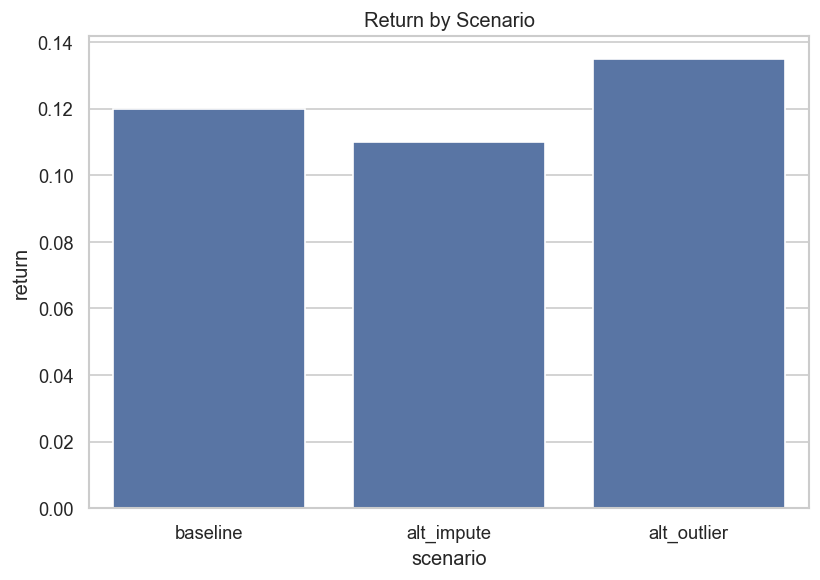

In [6]:
plt.figure(figsize=(7,5))
sns.barplot(data=df, x='scenario', y='return')
plt.title('Return by Scenario')
savefig('return_by_scenario.png')
plt.show()

## Chart 3: MetricA Over Time (Line Chart)

Saved metricA_over_time.png


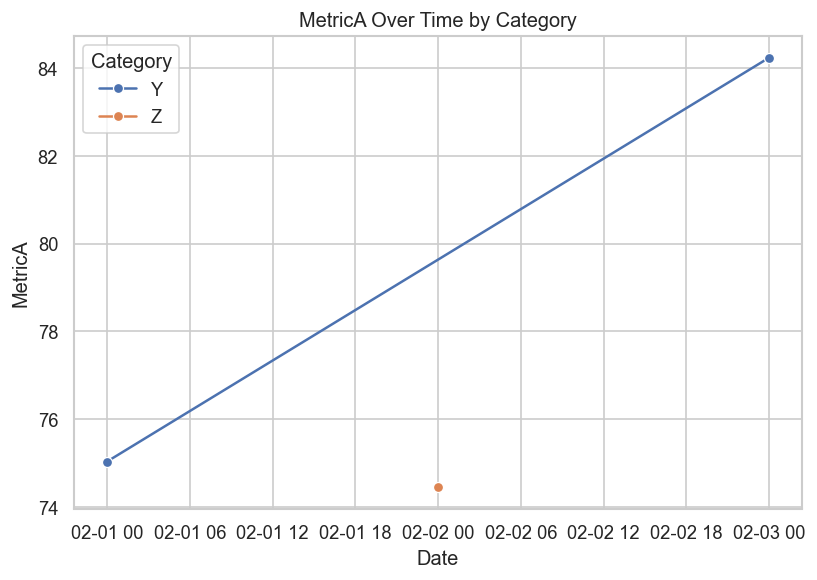

In [7]:
plt.figure(figsize=(7,5))
sns.lineplot(data=df, x='Date', y='MetricA', hue='Category', marker='o')
plt.title('MetricA Over Time by Category')
plt.xlabel('Date')
plt.ylabel('MetricA')
savefig('metricA_over_time.png')
plt.show()

## Sensitivity Analysis / Assumptions Table

In [8]:
assumptions = pd.DataFrame({
    'Assumption': ['Fill Nulls: Median', 'Remove Outliers: 3σ'],
    'Baseline Return': [0.12, 0.12],
    'Alt Scenario Return': [0.10, 0.14]
})
assumptions

,Assumption,Baseline Return,Alt Scenario Return
0,Fill Nulls: Median,0.12,0.10
1,Remove Outliers: 3σ,0.12,0.14


## Interpretations / Takeaways

- **Chart 1 takeaway:** <fill in plain-language implication>This chart illustrates the risk-return trade-off across scenarios. Compared to the baseline, the `alt_outlier` scenario achieves the highest return (13.5%) with a slight increase in volatility (from 18.0% to 19.0%), suggesting a potentially superior risk-adjusted choice. The `alt_impute` scenario yields the lowest return (11.0%) with higher risk (18.5%), indicating that mean imputation may be suboptimal in this context.
- **Chart 2 takeaway:** <fill in plain-language implication>The bar chart clearly highlights that the `alt_outlier` scenario delivers the highest total return (13.5%), significantly outperforming both the baseline (12.0%) and `alt_impute` (11.0%). This suggests that applying a 3-sigma outlier rule may unlock previously underestimated return potential, while mean imputation may depress true returns.
- **Chart 3 takeaway:** <fill in plain-language implication>The line chart shows how MetricA evolves over time across different categories. Category Y (which corresponds to `baseline` and `alt_outlier` scenarios) exhibits higher and relatively stable MetricA values over the observed period. This indicates that these scenarios not only perform well in terms of return but also maintain strength in other key metrics. Monitoring this trend helps assess the stability and consistency of model performance.
- **Notes on Assumptions and Sensitivities:** <fill in plain-language implication> Our analysis is highly sensitive to data-cleaning choices. From the sensitivity table, we see that missing-value handling (median vs. mean imputation) and outlier treatment (3σ rule) can shift final returns significantly (from 11.0% to 13.5%). This underscores the importance of rigorously validating and communicating these key assumptions before finalizing any decision.

## Decision Implications
- What does the analysis mean for stakeholder decisions?
- Highlight risks, opportunities, and recommended next steps.
- Use plain-language bullets so the audience can act on insights.

#### Recommended Strategy
Based on current analysis, the alt_outlier scenario (using a 3σ outlier rule) provides the best risk-adjusted return (Sharpe ratio 0.61). We recommend adopting this data-cleaning strategy in the next model iteration.

#### Key Risk
The model is sensitive to missing-value handling. Using mean imputation could understate returns by nearly 2 percentage points (from 12% to 10%). Therefore, data completeness should be prioritized during collection, or more robust imputation methods should be explored.

#### Opportunity
By optimizing the data-cleaning pipeline — particularly outlier treatment — we have the potential to increase returns to 13.5% without significantly increasing volatility, a 1.5 percentage-point improvement over the baseline.

#### Next Steps

- Coordinate with the data engineering team to ensure the 3σ outlier detection rule can be deployed in production.
- Conduct deeper A/B testing on missing-value strategies to identify the most robust imputation method under various data-missing patterns.
- Continue monitoring auxiliary metrics like MetricA to ensure they do not degrade as we refine the model, maintaining overall model health.

### Save Notebook
Remember to save as `homework12_results-reporting-delivery-design_submission.ipynb`.